In [2]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#import dataset and view first few columns
df = pd.read_csv('blood_cell_anomaly_detection.csv')
df.head(5)

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


In [4]:
df.columns

Index(['cell_id', 'cell_type', 'anomaly_label', 'disease_category',
       'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density',
       'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score',
       'lobularity_score', 'membrane_smoothness', 'cell_area_px',
       'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity',
       'patient_age_group', 'patient_sex', 'wbc_count_per_ul',
       'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct',
       'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl', 'dataset_source',
       'staining_protocol', 'microscope_model', 'magnification_x',
       'image_resolution_px', 'cytodiffusion_anomaly_score',
       'cytodiffusion_classification_confidence', 'labeller_confidence_score'],
      dtype='object')

In [5]:
df['disease_category'].unique()

array(['Infection', 'Normal_WBC', 'Normal_RBC', 'Artefact',
       'Normal_Platelet', 'Leukemia', 'Anemia', 'Sickle_Cell_Anemia'],
      dtype=object)

<Axes: xlabel='anomaly_label', ylabel='count'>

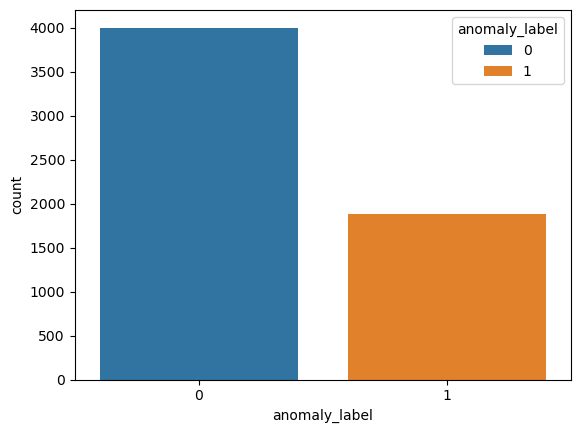

In [6]:
#viewing distribution of the anomally vs normal blood cell
sns.countplot(df, x='anomaly_label', hue='anomaly_label')

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Infection'),
  Text(1, 0, 'Normal_WBC'),
  Text(2, 0, 'Normal_RBC'),
  Text(3, 0, 'Artefact'),
  Text(4, 0, 'Normal_Platelet'),
  Text(5, 0, 'Leukemia'),
  Text(6, 0, 'Anemia'),
  Text(7, 0, 'Sickle_Cell_Anemia')])

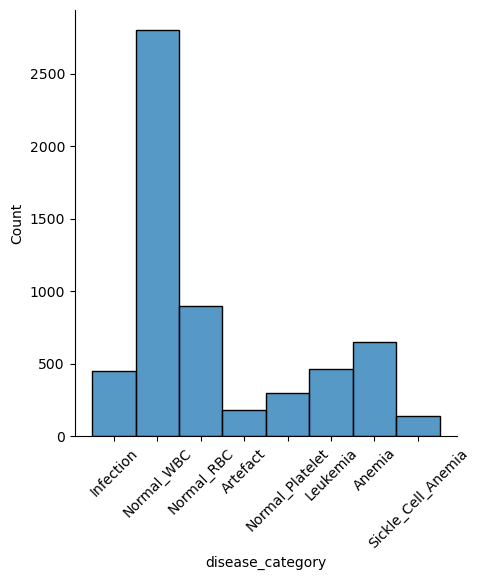

In [7]:
sns.displot(df, x='disease_category')
plt.xticks(rotation=45)

In [8]:
print('=== Data Types & Nulls ===')
info = pd.DataFrame({'dtype': df.dtypes, 'nulls': df.isnull().sum(), 'unique': df.nunique()})
print(info.to_string())

=== Data Types & Nulls ===
                                           dtype  nulls  unique
cell_id                                   object      0    5880
cell_type                                 object      0      19
anomaly_label                              int64      0       2
disease_category                          object      0       8
cell_diameter_um                         float64      0    1472
nucleus_area_pct                         float64      0     607
chromatin_density                        float64      0     730
cytoplasm_ratio                          float64      0     610
circularity                              float64      0     727
eccentricity                             float64      0     878
granularity_score                        float64      0     566
lobularity_score                         float64      0      63
membrane_smoothness                      float64      0     470
cell_area_px                               int64      0     752
perimeter_px 

In [9]:
#Try to explain this code and qwrite it in a simpler manner
morph_cols = ['cell_diameter_um','nucleus_area_pct','circularity','eccentricity',
              'granularity_score','lobularity_score','chromatin_density',
              'membrane_smoothness','cytodiffusion_anomaly_score']
df[morph_cols].describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
cell_diameter_um,5880.000000,10.176267,3.642051,1.000000,7.630000,10.055000,12.860000,21.180000
nucleus_area_pct,5880.000000,43.537976,33.419390,0.000000,0.000000,54.500000,72.300000,99.000000
circularity,5880.000000,0.769263,0.158219,0.100000,0.711000,0.805000,0.879000,1.000000
eccentricity,5880.000000,0.365458,0.201501,0.000000,0.214750,0.331000,0.456000,0.990000
granularity_score,5880.000000,1.882109,1.428336,0.000000,0.670000,1.320000,2.980000,6.000000
lobularity_score,5880.000000,1.769252,1.229362,1.000000,1.000000,1.000000,2.300000,7.200000
chromatin_density,5880.000000,0.391394,0.310006,0.000000,0.000000,0.479500,0.635000,1.000000
membrane_smoothness,5880.000000,0.842866,0.096033,0.290000,0.784000,0.854000,0.918000,1.000000
cytodiffusion_anomaly_score,5880.000000,0.317583,0.349655,0.000000,0.063675,0.113150,0.743850,1.000000


/var/folders/z7/8qmndvnj51d0663775d683ch0000gn/T/ipykernel_42764/403935074.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


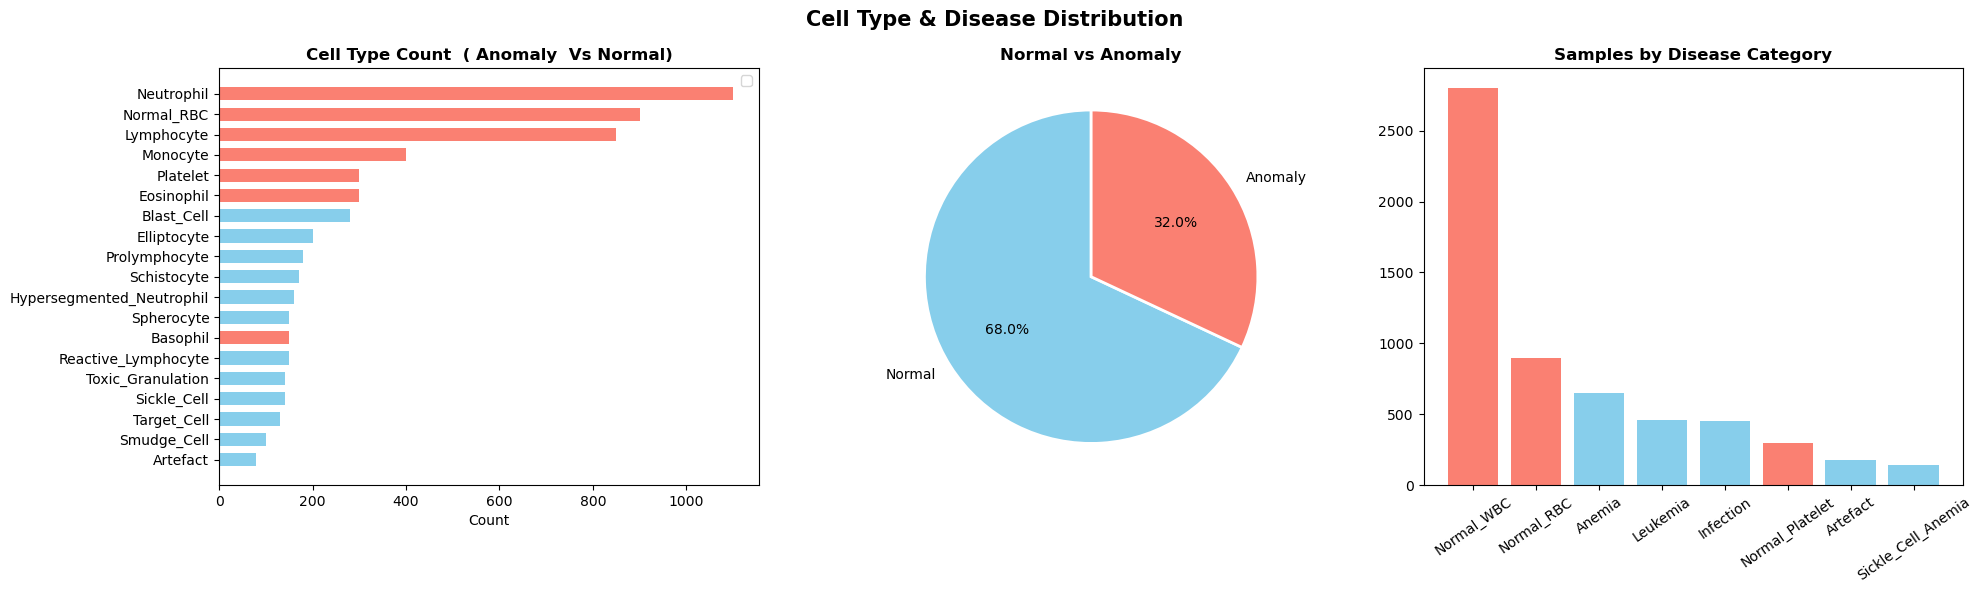

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Cell Type & Disease Distribution', fontsize=15, fontweight='bold')

# Cell type bar
vc = df['cell_type'].value_counts().sort_values()
colors = ['skyblue' if df[df.cell_type==c]['anomaly_label'].iloc[0]==1
          else 'salmon' for c in vc.index]
axes[0].barh(vc.index, vc.values, color=colors, edgecolor='none', height=0.65)
axes[0].set_title('Cell Type Count  ( Anomaly  Vs Normal)', fontweight='bold')
axes[0].legend()
axes[0].set_xlabel('Count')

# Anomaly pie
counts = df['anomaly_label'].value_counts()
axes[1].pie(counts.values, labels=['Normal','Anomaly'],
            colors= ['skyblue', 'salmon'], autopct='%1.1f%%',
            wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[1].set_title('Normal vs Anomaly', fontweight='bold')

# Disease category
cat_c = df['disease_category'].value_counts()
axes[2].bar(cat_c.index, cat_c.values,
            color=['skyblue' if c not in ['Normal_WBC','Normal_RBC','Normal_Platelet']
                   else 'salmon' for c in cat_c.index], edgecolor='none')
axes[2].set_title('Samples by Disease Category', fontweight='bold')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

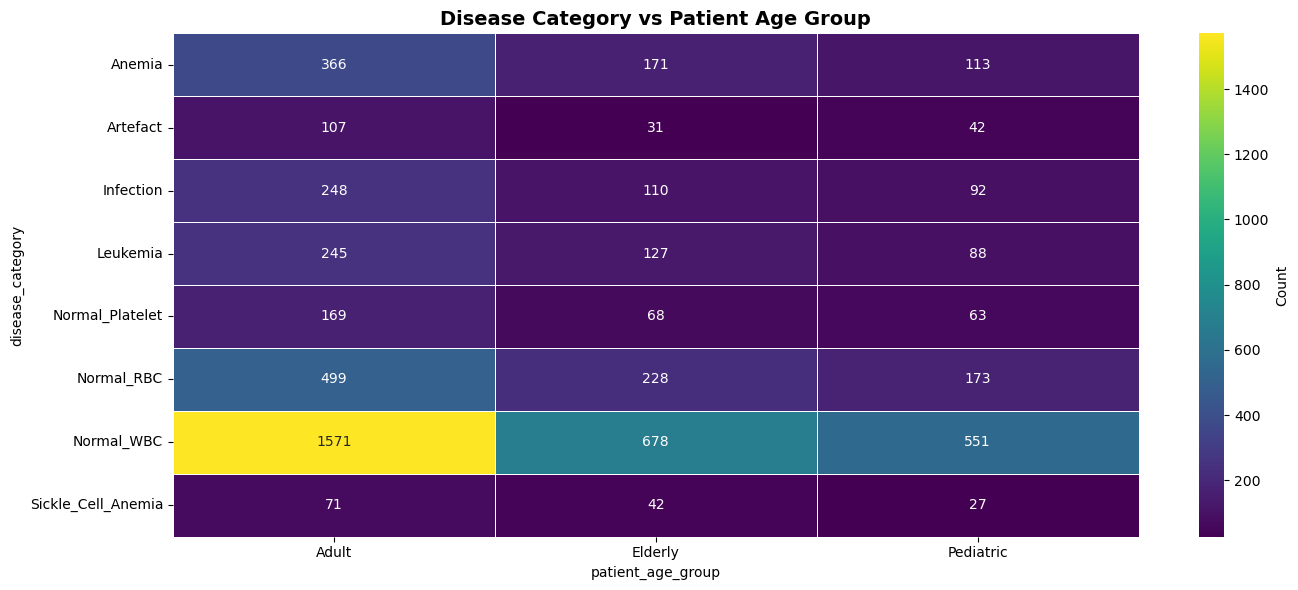

In [18]:
# Cross-tabulation: disease category vs patient age group
ct = pd.crosstab(df['disease_category'], df['patient_age_group'])
fig, ax = plt.subplots(figsize=(14, 6), facecolor='white')
sns.heatmap(ct, annot=True, fmt='d', cmap='viridis', ax=ax,
            linewidths=0.5, cbar_kws={'label':'Count'})
ax.set_title('Disease Category vs Patient Age Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

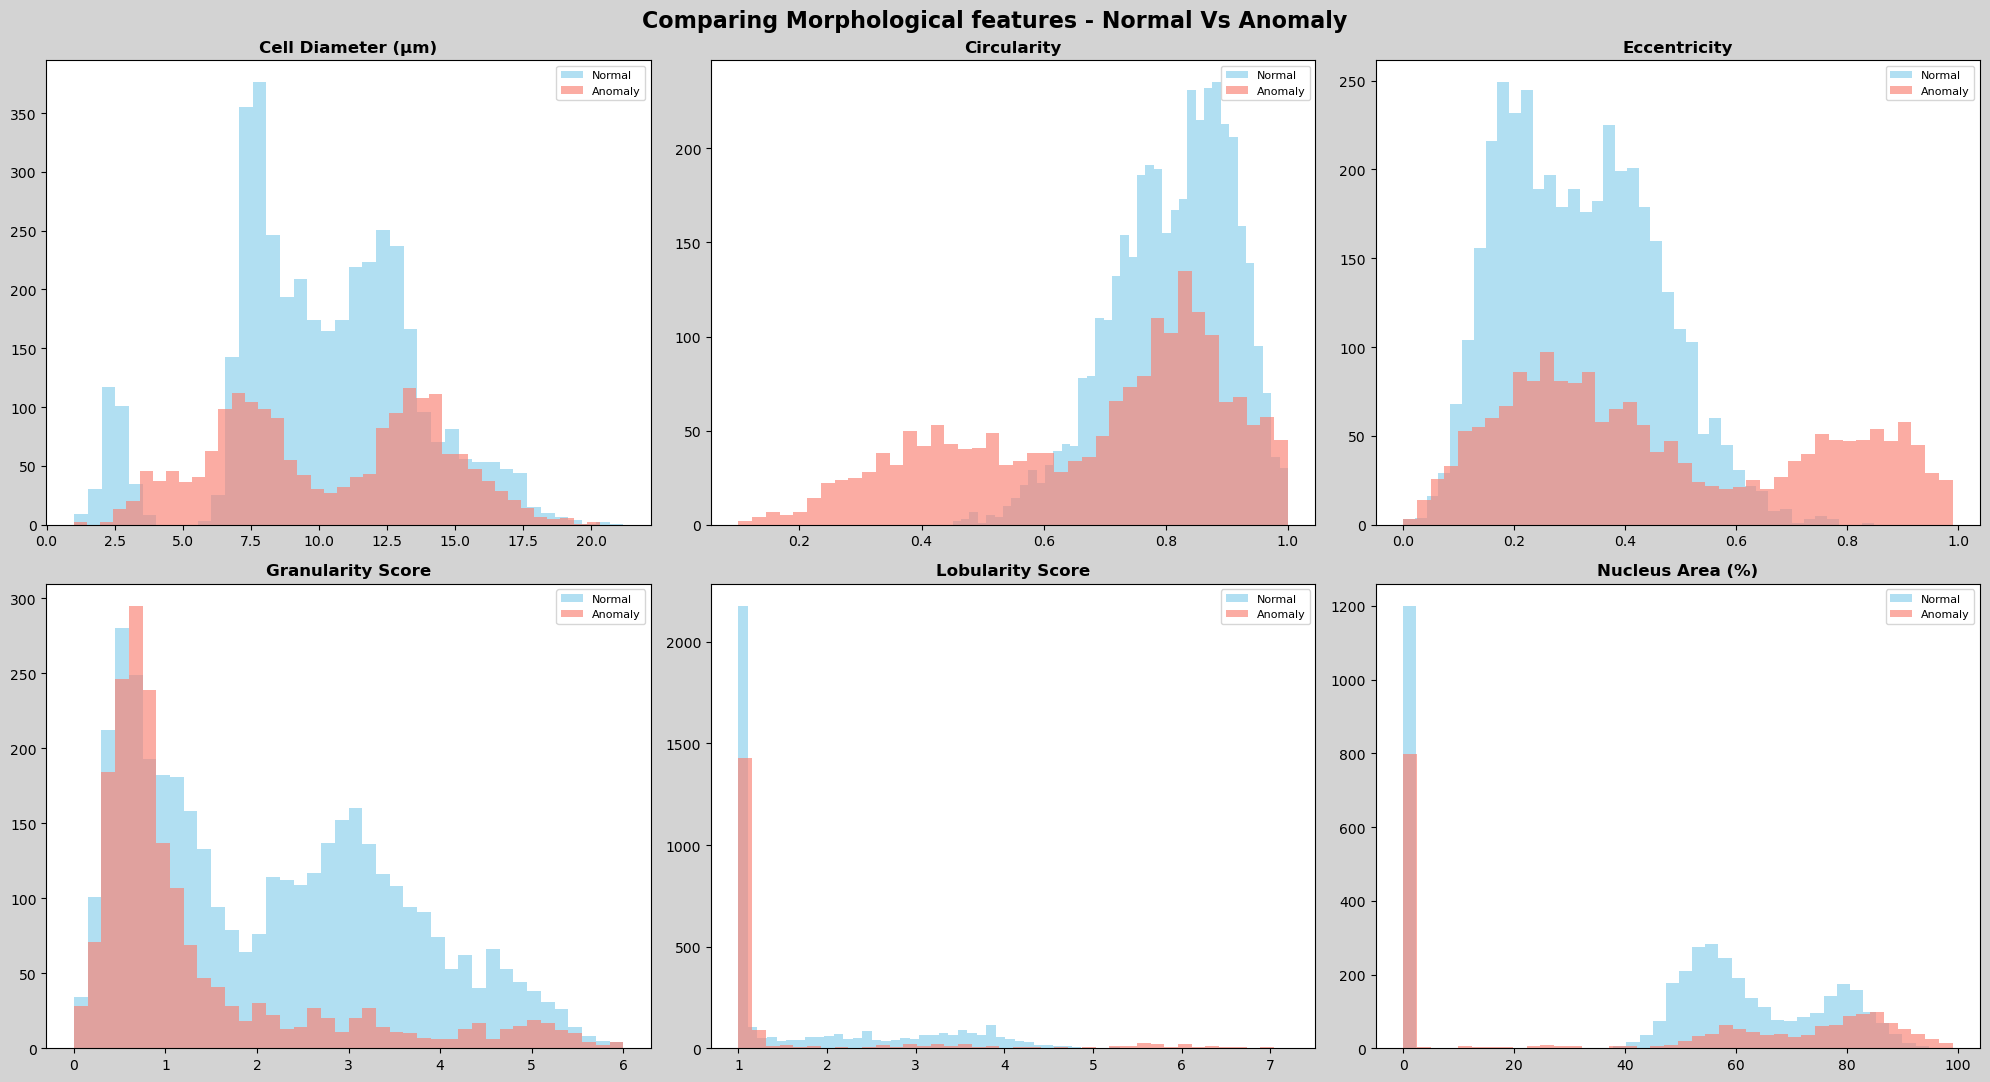

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11), facecolor='lightgrey')
fig.suptitle('Comparing Morphological features - Normal Vs Anomaly', fontsize=16, fontweight='bold')

features = ['cell_diameter_um','circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'nucleus_area_pct']
titles   = ['Cell Diameter (μm)', 'Circularity','Eccentricity','Granularity Score', 'Lobularity Score', 'Nucleus Area (%)']

for ax, feat, title in zip(axes.flatten(), features, titles):
    ax.hist(df[df.anomaly_label==0][feat], bins=40, alpha=0.65,
            color='skyblue', label='Normal', edgecolor='none')
    ax.hist(df[df.anomaly_label==1][feat], bins=40, alpha=0.65,
            color='salmon', label='Anomaly', edgecolor='none')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

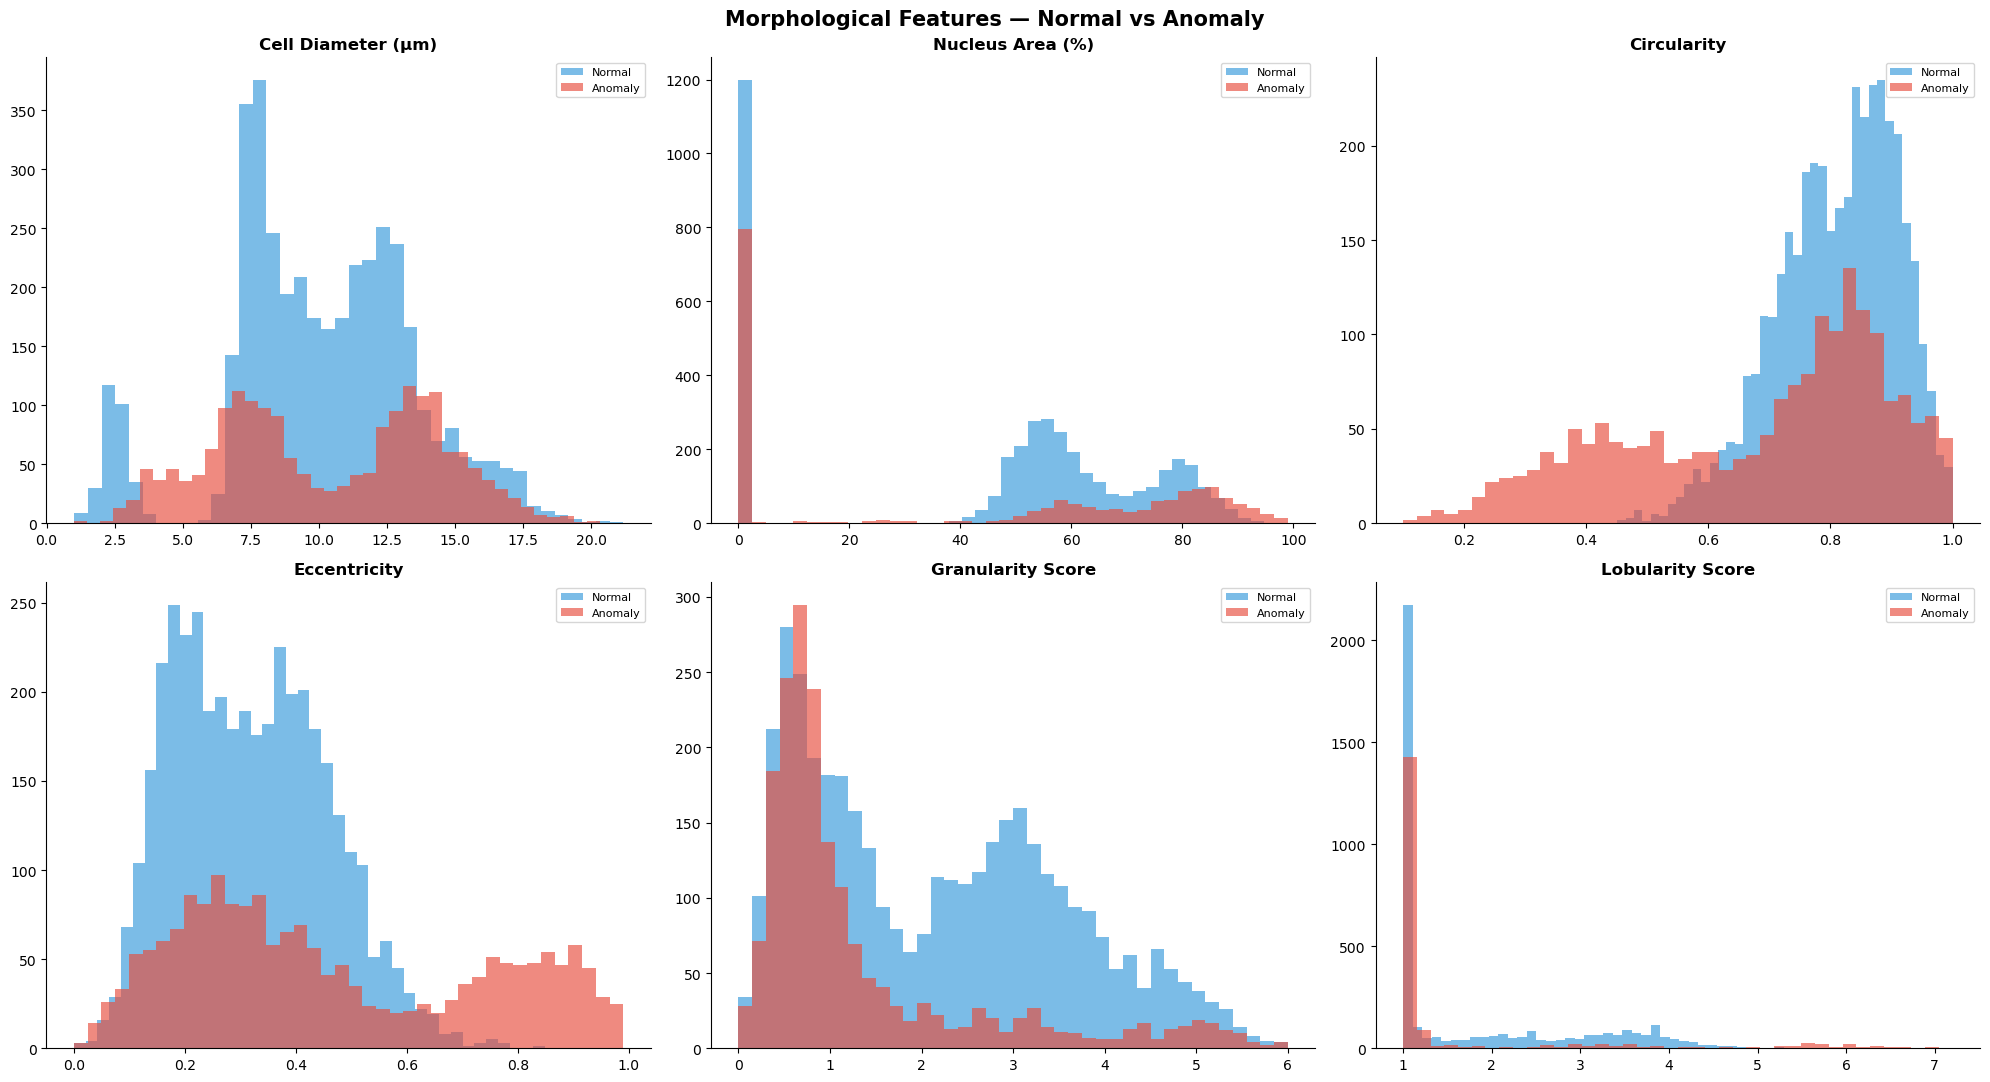

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11), facecolor='w')
fig.suptitle('Morphological Features — Normal vs Anomaly', fontsize=15, fontweight='bold')

features = ['cell_diameter_um','nucleus_area_pct','circularity',
            'eccentricity','granularity_score','lobularity_score']
titles   = ['Cell Diameter (μm)','Nucleus Area (%)','Circularity',
            'Eccentricity','Granularity Score','Lobularity Score']

for ax, feat, title in zip(axes.flatten(), features, titles):
    ax.hist(df[df.anomaly_label==0][feat], bins=40, alpha=0.65,
            color=PALETTE[2], label='Normal', edgecolor='none')
    ax.hist(df[df.anomaly_label==1][feat], bins=40, alpha=0.65,
            color=PALETTE[1], label='Anomaly', edgecolor='none')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


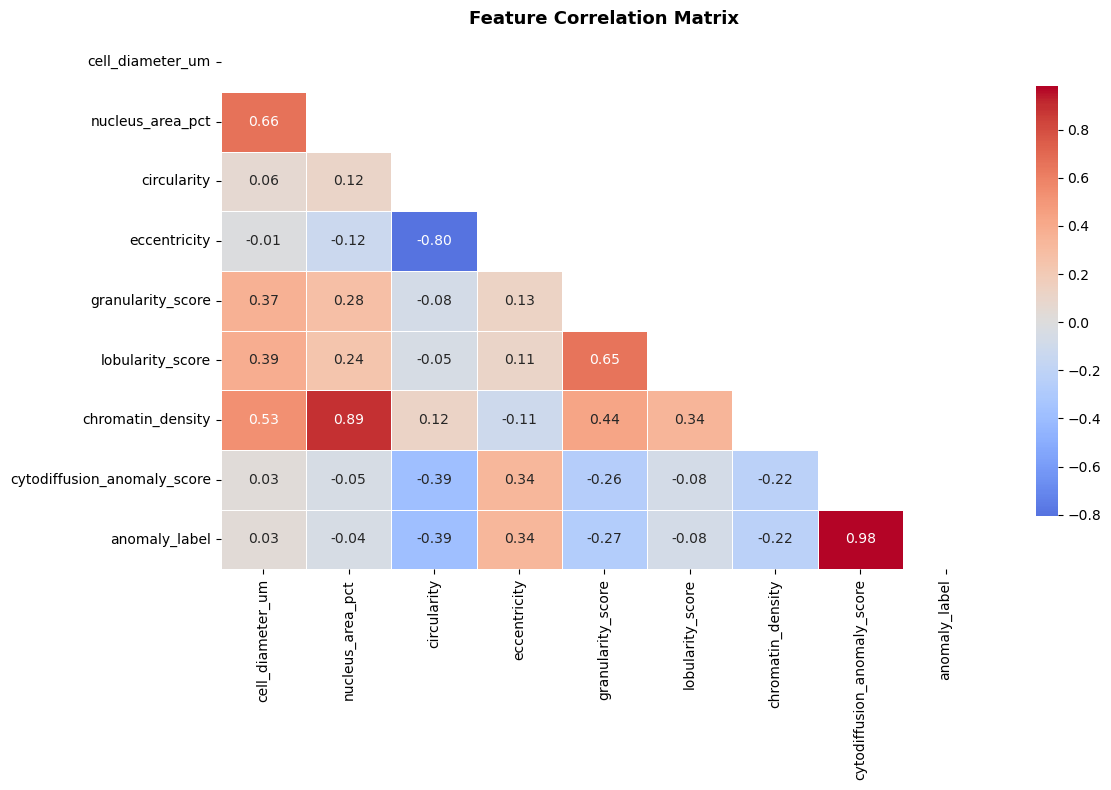

In [27]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(12, 8))
num_cols = ['cell_diameter_um','nucleus_area_pct','circularity','eccentricity',
            'granularity_score','lobularity_score','chromatin_density',
            'cytodiffusion_anomaly_score','anomaly_label']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.4, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

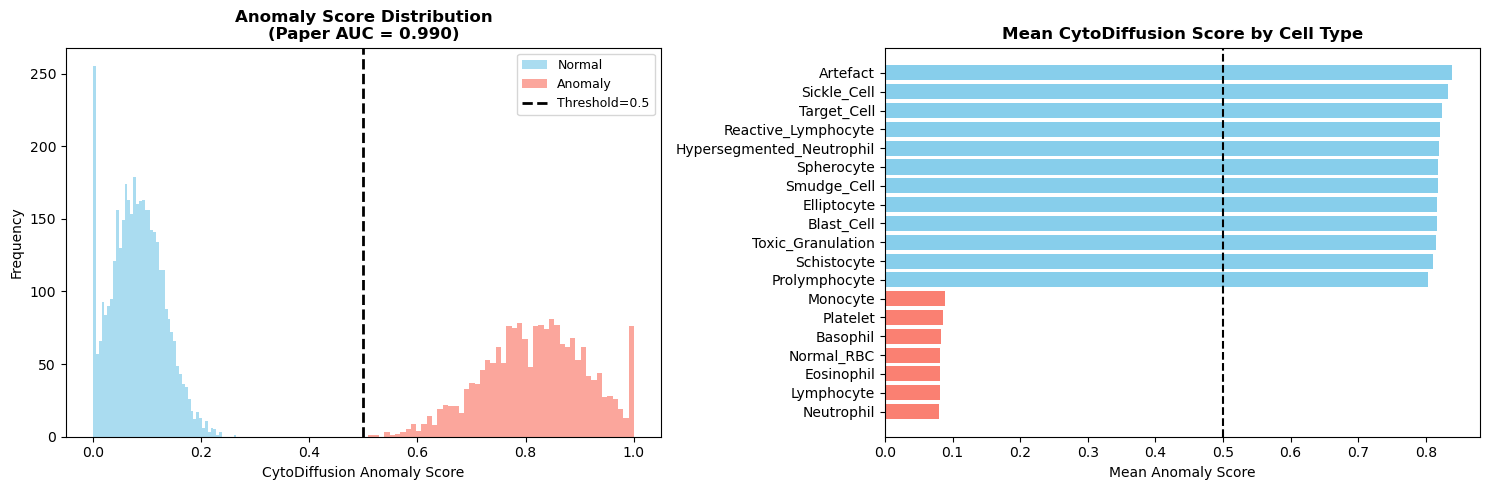

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Score distribution
axes[0].hist(df[df.anomaly_label==0]['cytodiffusion_anomaly_score'], bins=50,
             alpha=0.7, color='skyblue', label='Normal', edgecolor='none')
axes[0].hist(df[df.anomaly_label==1]['cytodiffusion_anomaly_score'], bins=50,
             alpha=0.7, color='salmon', label='Anomaly', edgecolor='none')
axes[0].axvline(0.5, color='black', lw=2, ls='--', label='Threshold=0.5')
axes[0].set_xlabel('CytoDiffusion Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Anomaly Score Distribution\n(Paper AUC = 0.990)', fontweight='bold')
axes[0].legend(fontsize=9)

# Score by cell type
ct_score = df.groupby('cell_type')['cytodiffusion_anomaly_score'].mean().sort_values()
colors_ct = ['skyblue' if df[df.cell_type==ct]['anomaly_label'].iloc[0]==1
             else 'salmon' for ct in ct_score.index]
axes[1].barh(ct_score.index, ct_score.values, color=colors_ct, edgecolor='none')
axes[1].axvline(0.5, color='black', lw=1.5, ls='--')
axes[1].set_xlabel('Mean Anomaly Score')
axes[1].set_title('Mean CytoDiffusion Score by Cell Type', fontweight='bold')

plt.tight_layout()
plt.show()

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)

In [44]:
# Feature preparation
features = ['cell_area_px', 'cell_diameter_um', 'chromatin_density', 'circularity',
                'cytoplasm_ratio', 'eccentricity', 'granularity_score','hemoglobin_g_dl',
                'hematocrit_pct', 'lobularity_score','membrane_smoothness', 'mean_r','mean_g','mean_b', 'mean_r','mean_g','mean_b', 'mcv_fl','mchc_g_dl',
                'nucleus_area_pct', 'perimeter_px', 'platelet_count_per_ul', 'rbc_count_millions_per_ul',
                'stain_intensity',
                'wbc_count_per_ul']

X = df[features].values
y = df['anomaly_label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Positive rate (train): {y_train.mean():.2%}')

Train: 4,704 | Test: 1,176
Positive rate (train): 31.97%


In [46]:
# Train models
models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=150, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'pred': y_pred, 'proba': y_proba,
                     'auc': auc, 'acc': acc}
    print(f'{name:25s} → AUC: {auc:.4f} | Accuracy: {acc:.4f}')

Random Forest             → AUC: 0.9977 | Accuracy: 0.9736
Gradient Boosting         → AUC: 0.9948 | Accuracy: 0.9753
Logistic Regression       → AUC: 0.8536 | Accuracy: 0.8461


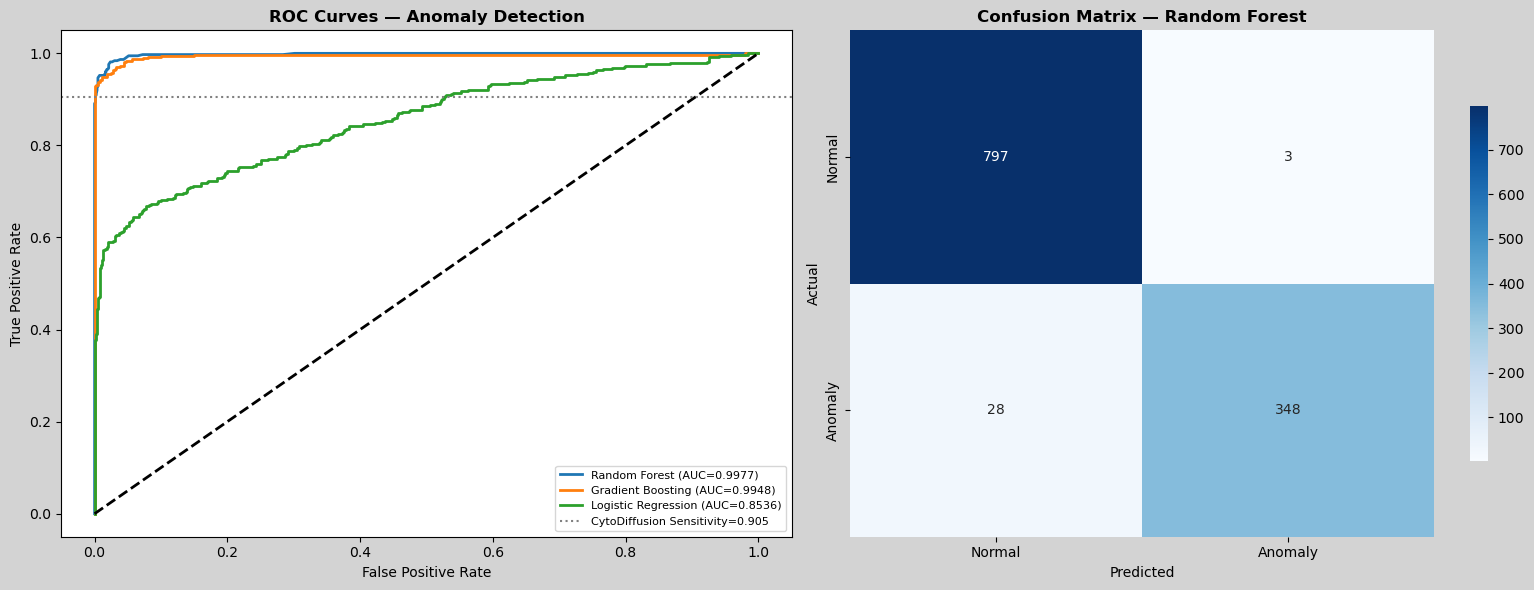


Best model: Random Forest
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98       800
     Anomaly       0.99      0.93      0.96       376

    accuracy                           0.97      1176
   macro avg       0.98      0.96      0.97      1176
weighted avg       0.97      0.97      0.97      1176



In [48]:
# ROC curves + confusion matrix for best model
best_name = max(results, key=lambda k: results[k]['auc'])
best      = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='lightgray')

# ROC curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={res['auc']:.4f})")
axes[0].plot([0,1],[0,1], 'k--', lw=2)
axes[0].axhline(0.905, color='gray', ls=':', lw=1.5, label='CytoDiffusion Sensitivity=0.905')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Anomaly Detection', fontweight='bold')
axes[0].legend(fontsize=8)

# Confusion matrix
cm = confusion_matrix(y_test, best['pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal','Anomaly'], yticklabels=['Normal','Anomaly'],
            cbar_kws={'shrink':0.7})
axes[1].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()
print(f'\nBest model: {best_name}')
print(classification_report(y_test, best['pred'], target_names=['Normal','Anomaly']))


In [49]:
le = LabelEncoder()
y_multi = le.fit_transform(df['cell_type'])

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_scaled, y_multi, test_size=0.20, random_state=42, stratify=y_multi)

rf_multi = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_multi.fit(X_tr2, y_tr2)
y_pred_multi = rf_multi.predict(X_te2)
acc_multi = accuracy_score(y_te2, y_pred_multi)
print(f'Multi-class Accuracy: {acc_multi:.4f}')
print()
print(classification_report(y_te2, y_pred_multi,
                             target_names=le.classes_))

Multi-class Accuracy: 0.9541

                           precision    recall  f1-score   support

                 Artefact       1.00      0.94      0.97        16
                 Basophil       0.97      1.00      0.98        30
               Blast_Cell       0.79      0.98      0.87        56
              Elliptocyte       0.95      1.00      0.98        40
               Eosinophil       0.97      0.95      0.96        60
Hypersegmented_Neutrophil       1.00      0.88      0.93        32
               Lymphocyte       1.00      1.00      1.00       170
                 Monocyte       0.98      1.00      0.99        80
               Neutrophil       0.96      0.98      0.97       220
               Normal_RBC       0.92      0.98      0.95       180
                 Platelet       1.00      1.00      1.00        60
            Prolymphocyte       0.95      0.58      0.72        36
      Reactive_Lymphocyte       1.00      0.93      0.97        30
              Schistocyte      

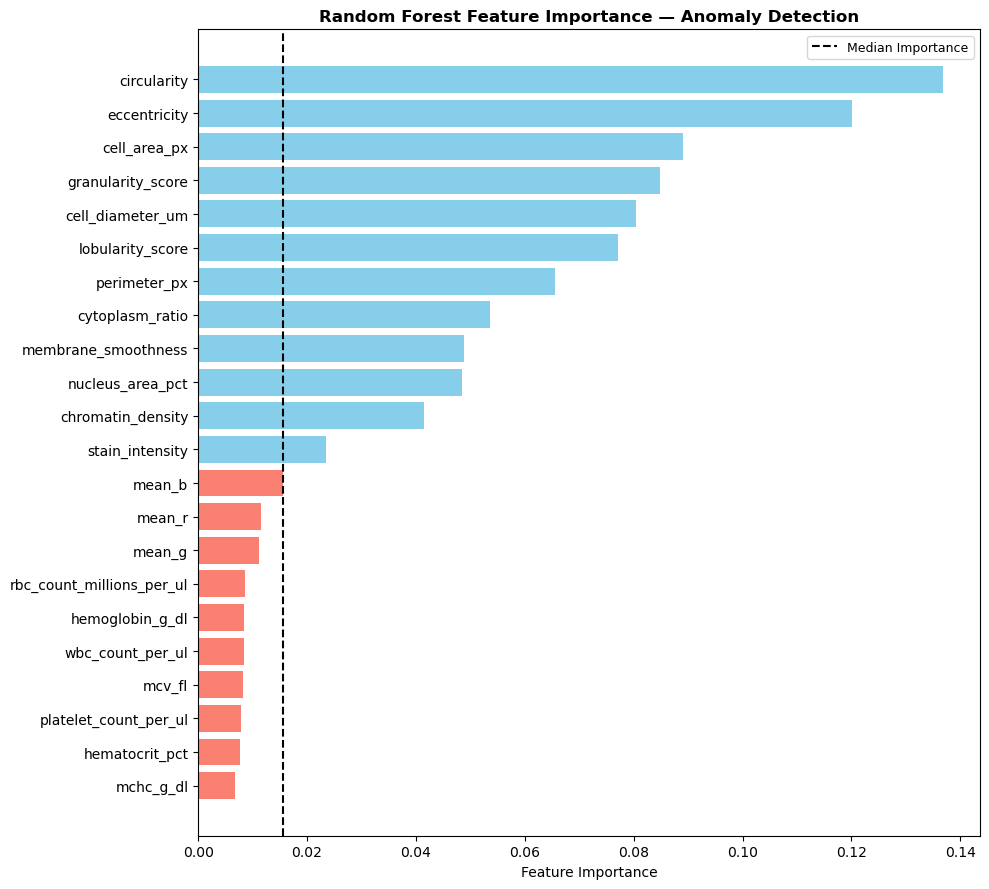


Top 5 most important features:
cell_diameter_um     0.080382
granularity_score    0.084842
cell_area_px         0.089101
eccentricity         0.120106
circularity          0.136780


In [51]:
# Feature importance from best binary RF
rf_binary = results['Random Forest']['model']
imp = pd.Series(rf_binary.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9), facecolor='white')
colors_imp = ['skyblue' if v > imp.median() else 'salmon' for v in imp.values]
ax.barh(imp.index, imp.values, color=colors_imp, edgecolor='none')
ax.axvline(imp.median(), color='black', lw=1.5, ls='--', label='Median Importance')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance — Anomaly Detection', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(imp.tail(5).to_string())